LQR Gain matrix K:
[[-10.         -10.5748011   59.63861446  13.43136873]]


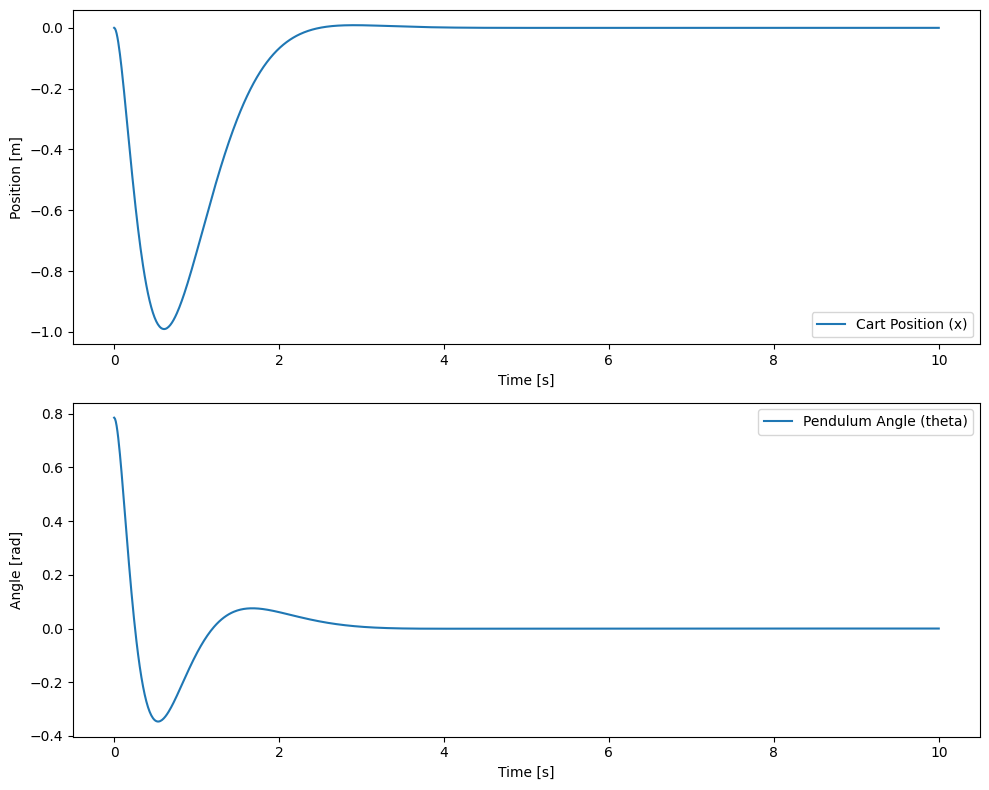

In [2]:
import numpy as np
from scipy.linalg import solve_continuous_are
import scipy.integrate
import matplotlib.pyplot as plt

# Parameters
M = 1.0    # Mass of the cart (kg)
m = 0.1    # Mass of the pendulum (kg)
b = 0.1    # Damping coefficient (N/m/sec)
l = 0.5    # Length to pendulum center of mass (m)
g = 9.8    # Acceleration due to gravity (m/s^2)

# State-space matrices
A = np.array([[0, 1, 0, 0],
              [0, -b/M, (m * g) / M, 0],
              [0, 0, 0, 1],
              [0, -b/(M*l), (M + m) * g / (M * l), 0]])

B = np.array([[0],
              [1/M],
              [0],
              [1/(M*l)]])

# Cost matrices
Q = np.diag([10, 1, 10, 1])
R = np.array([[0.1]])

# Solve the continuous-time algebraic Riccati equation (CARE)
P = solve_continuous_are(A, B, Q, R)

# Compute the LQR gain
K = np.linalg.inv(R) @ B.T @ P

print("LQR Gain matrix K:")
print(K)

# Control law: u = -K @ x
def lqr_control(x):
    u = -K @ x
    return u

# Simulate the system
def pendulum_dynamics(t, x):
    x = x.reshape(-1, 1)
    u = lqr_control(x)
    dxdt = A @ x + B @ u
    return dxdt.flatten()

# Initial state: [x, x_dot, theta, theta_dot]
x0 = np.array([0.0, 0.0, np.pi/4, 0.0])  # Starting with 45 degrees deviation

# Time vector
t = np.linspace(0, 10, 1000)

# Simulate the system using odeint
solution = scipy.integrate.solve_ivp(pendulum_dynamics, [t[0], t[-1]], x0, t_eval=t)

# Plot the results
plt.figure(figsize=(10, 8))
plt.subplot(2, 1, 1)
plt.plot(solution.t, solution.y[0], label='Cart Position (x)')
plt.xlabel('Time [s]')
plt.ylabel('Position [m]')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(solution.t, solution.y[2], label='Pendulum Angle (theta)')
plt.xlabel('Time [s]')
plt.ylabel('Angle [rad]')
plt.legend()

plt.tight_layout()
plt.show()


In [3]:
5 * np.random.rand(2,) 

array([0.01974504, 2.54079888])